In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load train and test sets (already split temporally in 01_etl.ipynb)
btc_train = pd.read_csv('../data/processed/BTC_USDT_train.csv')
btc_test  = pd.read_csv('../data/processed/BTC_USDT_test.csv')
eth_train = pd.read_csv('../data/processed/ETH_USDT_train.csv')
eth_test  = pd.read_csv('../data/processed/ETH_USDT_test.csv')

# Convert timestamps
for df in [btc_train, btc_test, eth_train, eth_test]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

print("BTC train:", btc_train.shape)
print(f"  Period: {btc_train['timestamp'].iloc[0]} → {btc_train['timestamp'].iloc[-1]}")
print(f"  Labels: {btc_train['label'].value_counts().to_dict()}")

print("\nBTC test:", btc_test.shape)
print(f"  Period: {btc_test['timestamp'].iloc[0]} → {btc_test['timestamp'].iloc[-1]}")
print(f"  Labels: {btc_test['label'].value_counts().to_dict()}")

print("\nETH train:", eth_train.shape)
print(f"  Period: {eth_train['timestamp'].iloc[0]} → {eth_train['timestamp'].iloc[-1]}")

print("\nETH test:", eth_test.shape)
print(f"  Period: {eth_test['timestamp'].iloc[0]} → {eth_test['timestamp'].iloc[-1]}")

BTC train: (2862, 36)
  Period: 2025-02-04 17:00:00 → 2025-12-31 20:00:00
  Labels: {1: 1466, 0: 733, 2: 663}

BTC test: (1983, 36)
  Period: 2025-12-31 22:00:00 → 2026-03-24 12:00:00
  Labels: {1: 1471, 0: 263, 2: 249}

ETH train: (5847, 36)
  Period: 2025-02-04 11:00:00 → 2025-12-31 21:00:00

ETH test: (1983, 36)
  Period: 2025-12-31 22:00:00 → 2026-03-24 12:00:00


In [3]:
DROP_COLS = ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'future_return']
FEATURE_COLS = [c for c in btc_train.columns if c not in DROP_COLS + ['label']]
TARGET_COL = 'label'

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of features: 28
Features: ['ma20', 'ma50', 'rsi', 'returns', 'vol_20', 'macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'atr', 'stoch_rsi', 'stoch_rsi_k', 'stoch_rsi_d', 'close_lag_1', 'returns_lag_1', 'close_lag_2', 'returns_lag_2', 'close_lag_3', 'returns_lag_3', 'close_lag_6', 'returns_lag_6', 'close_lag_12', 'returns_lag_12', 'close_lag_24', 'returns_lag_24']


In [4]:
# Extract features and labels
btc_X_train = btc_train[FEATURE_COLS]
btc_y_train = btc_train[TARGET_COL]
btc_X_test  = btc_test[FEATURE_COLS]
btc_y_test  = btc_test[TARGET_COL]

eth_X_train = eth_train[FEATURE_COLS]
eth_y_train = eth_train[TARGET_COL]
eth_X_test  = eth_test[FEATURE_COLS]
eth_y_test  = eth_test[TARGET_COL]

# Scale features (for Neural Network)
btc_scaler = StandardScaler()
btc_X_train_sc = btc_scaler.fit_transform(btc_X_train)
btc_X_test_sc  = btc_scaler.transform(btc_X_test)

eth_scaler = StandardScaler()
eth_X_train_sc = eth_scaler.fit_transform(eth_X_train)
eth_X_test_sc  = eth_scaler.transform(eth_X_test)

print(f"BTC → Train: {btc_X_train.shape} | Test: {btc_X_test.shape}")
print(f"ETH → Train: {eth_X_train.shape} | Test: {eth_X_test.shape}")

BTC → Train: (2862, 28) | Test: (1983, 28)
ETH → Train: (5847, 28) | Test: (1983, 28)


In [5]:
print("Training Random Forest...")
print("="*50)

rf_btc = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_btc.fit(btc_X_train, btc_y_train)
rf_btc_pred = rf_btc.predict(btc_X_test)

print("BTC - Random Forest:")
print(f"  Accuracy: {accuracy_score(btc_y_test, rf_btc_pred)*100:.2f}%")
print(classification_report(btc_y_test, rf_btc_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

rf_eth = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_eth.fit(eth_X_train, eth_y_train)
rf_eth_pred = rf_eth.predict(eth_X_test)

print("ETH - Random Forest:")
print(f"  Accuracy: {accuracy_score(eth_y_test, rf_eth_pred)*100:.2f}%")
print(classification_report(eth_y_test, rf_eth_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

Training Random Forest...
BTC - Random Forest:
  Accuracy: 38.43%
              precision    recall  f1-score   support

        SELL       0.17      0.32      0.22       263
        HOLD       0.85      0.37      0.52      1471
         BUY       0.16      0.53      0.25       249

    accuracy                           0.38      1983
   macro avg       0.39      0.41      0.33      1983
weighted avg       0.67      0.38      0.44      1983

ETH - Random Forest:
  Accuracy: 61.98%
              precision    recall  f1-score   support

        SELL       0.24      0.02      0.04       380
        HOLD       0.68      0.90      0.77      1283
         BUY       0.27      0.20      0.23       320

    accuracy                           0.62      1983
   macro avg       0.39      0.37      0.35      1983
weighted avg       0.53      0.62      0.54      1983



In [6]:
print("Training XGBoost...")
print("="*50)

xgb_btc = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_btc.fit(btc_X_train, btc_y_train)
xgb_btc_pred = xgb_btc.predict(btc_X_test)

print("BTC - XGBoost:")
print(f"  Accuracy: {accuracy_score(btc_y_test, xgb_btc_pred)*100:.2f}%")
print(classification_report(btc_y_test, xgb_btc_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

xgb_eth = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_eth.fit(eth_X_train, eth_y_train)
xgb_eth_pred = xgb_eth.predict(eth_X_test)

print("ETH - XGBoost:")
print(f"  Accuracy: {accuracy_score(eth_y_test, xgb_eth_pred)*100:.2f}%")
print(classification_report(eth_y_test, xgb_eth_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

Training XGBoost...
BTC - XGBoost:
  Accuracy: 41.30%
              precision    recall  f1-score   support

        SELL       0.17      0.22      0.19       263
        HOLD       0.81      0.43      0.56      1471
         BUY       0.15      0.53      0.24       249

    accuracy                           0.41      1983
   macro avg       0.38      0.39      0.33      1983
weighted avg       0.65      0.41      0.47      1983

ETH - XGBoost:
  Accuracy: 57.34%
              precision    recall  f1-score   support

        SELL       0.22      0.10      0.14       380
        HOLD       0.68      0.80      0.73      1283
         BUY       0.24      0.23      0.23       320

    accuracy                           0.57      1983
   macro avg       0.38      0.38      0.37      1983
weighted avg       0.52      0.57      0.54      1983



In [7]:
print("Training Neural Network...")
print("="*50)

nn_btc = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
nn_btc.fit(btc_X_train_sc, btc_y_train)
nn_btc_pred = nn_btc.predict(btc_X_test_sc)

print("BTC - Neural Network:")
print(f"  Accuracy: {accuracy_score(btc_y_test, nn_btc_pred)*100:.2f}%")
print(classification_report(btc_y_test, nn_btc_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

nn_eth = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
nn_eth.fit(eth_X_train_sc, eth_y_train)
nn_eth_pred = nn_eth.predict(eth_X_test_sc)

print("ETH - Neural Network:")
print(f"  Accuracy: {accuracy_score(eth_y_test, nn_eth_pred)*100:.2f}%")
print(classification_report(eth_y_test, nn_eth_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

Training Neural Network...
BTC - Neural Network:
  Accuracy: 55.77%
              precision    recall  f1-score   support

        SELL       0.18      0.05      0.07       263
        HOLD       0.80      0.65      0.72      1471
         BUY       0.19      0.54      0.28       249

    accuracy                           0.56      1983
   macro avg       0.39      0.41      0.36      1983
weighted avg       0.64      0.56      0.58      1983

ETH - Neural Network:
  Accuracy: 58.85%
              precision    recall  f1-score   support

        SELL       0.17      0.04      0.07       380
        HOLD       0.68      0.85      0.75      1283
         BUY       0.22      0.20      0.21       320

    accuracy                           0.59      1983
   macro avg       0.36      0.36      0.34      1983
weighted avg       0.51      0.59      0.54      1983



Model Comparison:
         Model  BTC Accuracy  ETH Accuracy   Average
Neural Network     55.774080     58.850227 57.312153
 Random Forest     38.426626     61.976803 50.201715
       XGBoost     41.301059     57.337368 49.319213

Best model overall: Neural Network
Best BTC model: Neural Network
Best ETH model: Random Forest


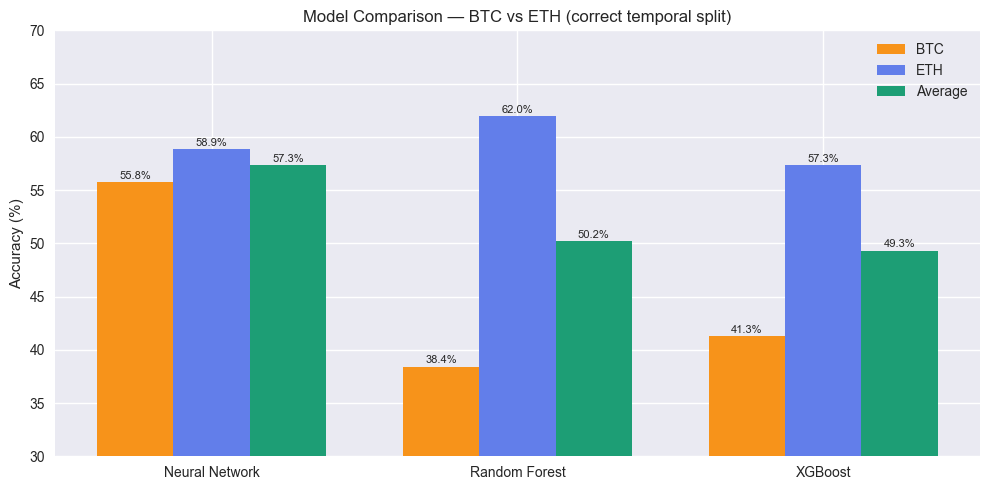

Chart saved!


In [8]:
results = {
    'Model': ['Random Forest', 'XGBoost', 'Neural Network'],
    'BTC Accuracy': [
        accuracy_score(btc_y_test, rf_btc_pred)*100,
        accuracy_score(btc_y_test, xgb_btc_pred)*100,
        accuracy_score(btc_y_test, nn_btc_pred)*100,
    ],
    'ETH Accuracy': [
        accuracy_score(eth_y_test, rf_eth_pred)*100,
        accuracy_score(eth_y_test, xgb_eth_pred)*100,
        accuracy_score(eth_y_test, nn_eth_pred)*100,
    ]
}

results_df = pd.DataFrame(results)
results_df['Average'] = (results_df['BTC Accuracy'] + results_df['ETH Accuracy']) / 2
results_df = results_df.sort_values('Average', ascending=False).reset_index(drop=True)

print("Model Comparison:")
print("="*55)
print(results_df.to_string(index=False))
print("="*55)
print(f"\nBest model overall: {results_df.iloc[0]['Model']}")
print(f"Best BTC model: {results_df.loc[results_df['BTC Accuracy'].idxmax(), 'Model']}")
print(f"Best ETH model: {results_df.loc[results_df['ETH Accuracy'].idxmax(), 'Model']}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.25
bars1 = ax.bar(x - width, results_df['BTC Accuracy'], width, label='BTC', color='#F7931A')
bars2 = ax.bar(x,         results_df['ETH Accuracy'], width, label='ETH', color='#627EEA')
bars3 = ax.bar(x + width, results_df['Average'],      width, label='Average', color='#1D9E75')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison — BTC vs ETH (correct temporal split)')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim(30, 70)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../docs/diagrams/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
import joblib
import os

os.makedirs('../data/models', exist_ok=True)

# Best overall: Neural Network
# Best BTC: Neural Network
# Best ETH: Random Forest

joblib.dump(nn_btc,  '../data/models/nn_btc.joblib')
joblib.dump(nn_eth,  '../data/models/nn_eth.joblib')
joblib.dump(rf_btc,  '../data/models/rf_btc.joblib')
joblib.dump(rf_eth,  '../data/models/rf_eth.joblib')
joblib.dump(xgb_btc, '../data/models/xgb_btc.joblib')
joblib.dump(xgb_eth, '../data/models/xgb_eth.joblib')

# Save scalers (needed for Neural Network)
joblib.dump(btc_scaler, '../data/models/scaler_btc.joblib')
joblib.dump(eth_scaler, '../data/models/scaler_eth.joblib')

# Save best models explicitly
joblib.dump(nn_btc, '../data/models/best_btc.joblib')
joblib.dump(rf_eth, '../data/models/best_eth.joblib')
joblib.dump(btc_scaler, '../data/models/best_btc_scaler.joblib')

print("Models saved to data/models/:")
for f in sorted(os.listdir('../data/models')):
    size = os.path.getsize(f'../data/models/{f}') / 1024
    print(f"  {f} ({size:.1f} KB)")

Models saved to data/models/:
  .gitkeep (0.0 KB)
  best_btc.joblib (340.0 KB)
  best_btc_scaler.joblib (1.8 KB)
  best_eth.joblib (4441.3 KB)
  nn_btc.joblib (340.0 KB)
  nn_eth.joblib (340.0 KB)
  rf_btc.joblib (3360.7 KB)
  rf_eth.joblib (4441.3 KB)
  scaler_btc.joblib (1.8 KB)
  scaler_eth.joblib (1.8 KB)
  xgb_btc.joblib (1840.3 KB)
  xgb_eth.joblib (2068.5 KB)


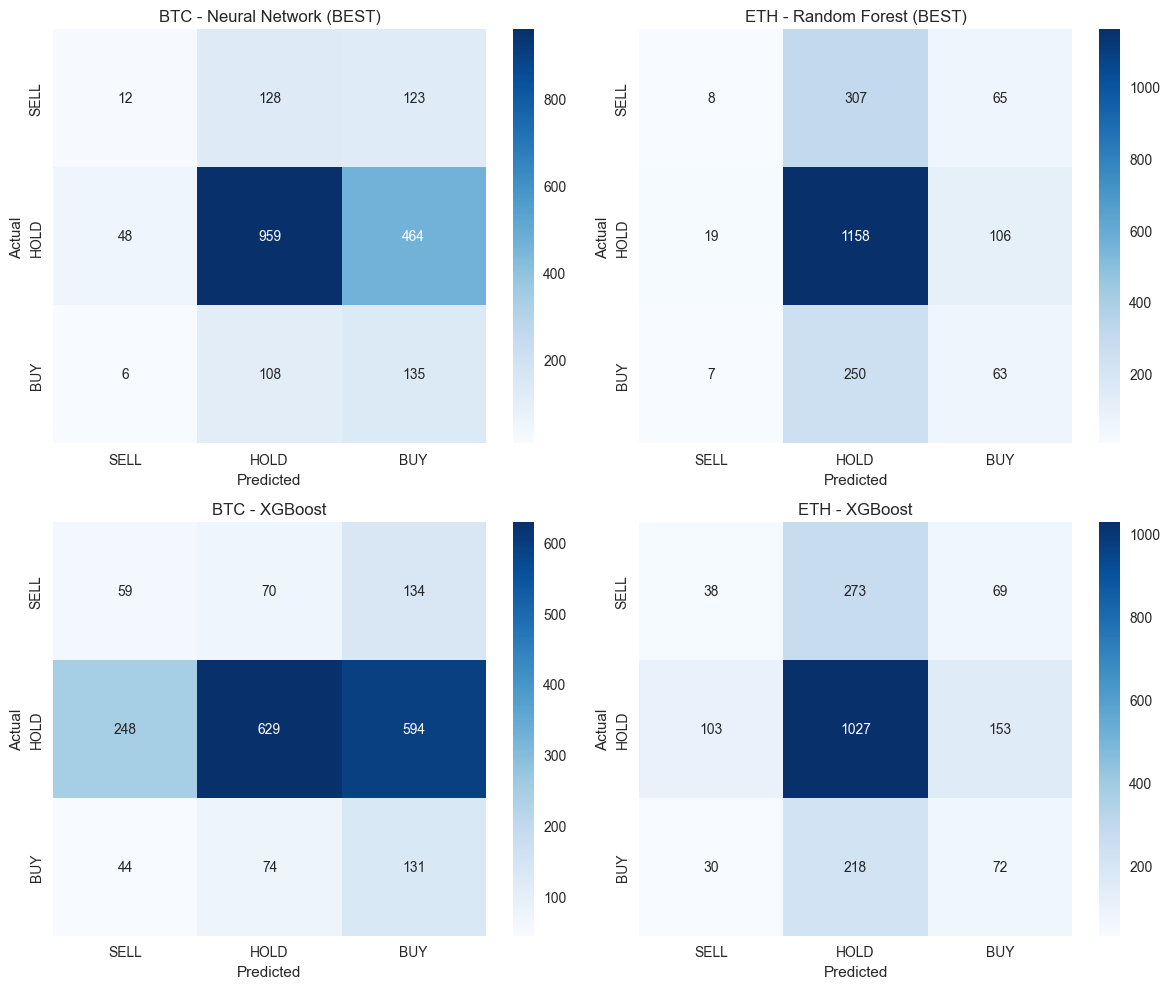

Confusion matrices saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
label_names = ['SELL', 'HOLD', 'BUY']

pairs = [
    (btc_y_test, nn_btc_pred,  'BTC - Neural Network (BEST)', axes[0][0]),
    (eth_y_test, rf_eth_pred,  'ETH - Random Forest (BEST)',  axes[0][1]),
    (btc_y_test, xgb_btc_pred, 'BTC - XGBoost',               axes[1][0]),
    (eth_y_test, xgb_eth_pred, 'ETH - XGBoost',               axes[1][1]),
]

for y_true, y_pred, title, ax in pairs:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../docs/diagrams/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")